# U.S. Business Formation Statistics: What Do New Business Applications Tell Us About the American Economy?
## Udacity Data Scientist Nanodegree Project 1 - By Fahad Masood Reda

**Dataset:** [U.S. Census Bureau — Business Formation Statistics (BFS)](https://www.census.gov/econ/bfs/index.html)

## 1. Business Understanding

The U.S. Census Bureau publishes weekly **Business Formation Statistics (BFS)**, which count the applications that people file
with the IRS to start a new business (Employer Identification Number applications). These filings are one of the earliest
available signals of entrepreneurial activity in the economy, available well before GDP, payrolls, or other lagging indicators.

This project uses two files published by the Census Bureau:

- **`bfs_state_apps_weekly_nsa.csv`** — weekly, **not seasonally adjusted (NSA)**, business application counts by U.S. state,
  covering 2006 through mid-2026. It reports four measures: total applications (`BA_NSA`), high-propensity applications
  (`HBA_NSA`, i.e. applications with characteristics that make them likely to turn into an actual employer business),
  applications with planned wages (`WBA_NSA`), and applications from corporations (`CBA_NSA`) — plus each measure's
  year-over-year percent change.
- **`date_table.csv`** — a lookup table that maps each `(Year, Week)` pair used by the BFS file to a real calendar start/end date.

### Business questions

Following the **CRISP-DM** process (Business Understanding → Data Understanding → Data Preparation → Modeling/Analysis →
Evaluation → Communication), this notebook answers five business questions:

1. **How have national business applications trended between 2006 and 2026, and how did the COVID-19 pandemic affect them?**
2. **Which U.S. states lead in business formation — both in absolute volume and in growth over the last decade?**
3. **Is there a seasonal pattern to when people file new business applications during the year?**
4. **What share of new applications are "high-propensity," and how has that share changed over time?**
5. **Can we predict weekly, state-level business applications from year, week-of-year, and state — and which of these factors
   matters most?**

Each question is answered with a supporting visualization, table, or statistic, and Question 5 is answered with a machine
learning model.


## 2. Data Understanding

We start by loading both files and inspecting their shape, types, and quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
COLOR = '#2E5EAA'   # primary color used across all charts
ACCENT = '#E8743B'  # accent color used to highlight key points (e.g. COVID period)

bfs = pd.read_csv('data/bfs_state_apps_weekly_nsa.csv')
dates = pd.read_csv('data/date_table.csv')

print('bfs shape  :', bfs.shape)
print('dates shape:', dates.shape)
bfs.head()

bfs shape  : (54468, 11)
dates shape: (1095, 4)


,Year,Week,State,BA_NSA,HBA_NSA,WBA_NSA,CBA_NSA,YY_BA_NSA,YY_HBA_NSA,YY_WBA_NSA,YY_CBA_NSA
0,2006,1,AK,90,60,50,30,NaN,NaN,NaN,NaN
1,2006,2,AK,90,60,40,30,NaN,NaN,NaN,NaN
2,2006,3,AK,130,90,70,40,NaN,NaN,NaN,NaN
3,2006,4,AK,100,60,40,20,NaN,NaN,NaN,NaN
4,2006,5,AK,150,80,60,30,NaN,NaN,NaN,NaN


In [2]:
bfs.dtypes

Year            int64
Week            int64
State          object
BA_NSA          int64
HBA_NSA         int64
WBA_NSA         int64
CBA_NSA         int64
YY_BA_NSA     float64
YY_HBA_NSA    float64
YY_WBA_NSA    float64
YY_CBA_NSA    float64
dtype: object

In [3]:
dates.head()

,Year,Week,Start date,End date
0,2006,1,1/1/2006,1/7/2006
1,2006,2,1/8/2006,1/14/2006
2,2006,3,1/15/2006,1/21/2006
3,2006,4,1/22/2006,1/28/2006
4,2006,5,1/29/2006,2/4/2006


In [4]:
# How many states/territories are covered, and what year range does the data span?
print('Number of unique states/territories:', bfs['State'].nunique())
print('Year range:', bfs['Year'].min(), '-', bfs['Year'].max())
print()
print('Missing values per column:')
print(bfs.isna().sum())

Number of unique states/territories: 51
Year range: 2006 - 2026

Missing values per column:
Year             0
Week             0
State            0
BA_NSA           0
HBA_NSA          0
WBA_NSA          0
CBA_NSA          0
YY_BA_NSA     2805
YY_HBA_NSA    2805
YY_WBA_NSA    2805
YY_CBA_NSA    2805
dtype: int64


The only missing values are in the four **year-over-year percent-change** columns (`YY_*_NSA`), which is expected:
a year-over-year change cannot be computed for the very first year of data (2006), since there is no "prior year" to compare
against. We also confirm there are no duplicate `(Year, Week, State)` records, and no duplicate `(Year, Week)` records in the
date lookup table.

In [5]:
print('Duplicate (Year, Week, State) rows in bfs   :', bfs.duplicated(subset=['Year', 'Week', 'State']).sum())
print('Duplicate (Year, Week) rows in date_table   :', dates.duplicated(subset=['Year', 'Week']).sum())
print('Rows in bfs with missing YY_BA_NSA that ARE in 2006:',
      ((bfs['YY_BA_NSA'].isna()) & (bfs['Year'] == 2006)).sum(), '/', (bfs['Year'] == 2006).sum())

Duplicate (Year, Week, State) rows in bfs   : 0
Duplicate (Year, Week) rows in date_table   : 0
Rows in bfs with missing YY_BA_NSA that ARE in 2006: 2652 / 2652


## 3. Data Preparation

To prepare the data for analysis we:

1. **Merge** the BFS weekly counts with the date lookup table on `(Year, Week)`, so every row has a real calendar date.
2. **Engineer** `Month` and `Quarter` features from the new date column, to support the seasonality analysis (Question 3).
3. **Handle missing values**: the `YY_*_NSA` (year-over-year change) columns are missing only for 2006, since there is no prior
   year to compare to. Rather than impute these values (which would fabricate a trend that doesn't exist), we leave them as
   missing and simply exclude them from any calculation that needs a full history — this is the appropriate approach here
   because the missingness is *structural* (a real absence of information), not random or the result of a data-collection
   error.
4. **Handle partial years**: 2026 is not yet complete in the data (it stops partway through the year), so any analysis that
   compares full calendar years excludes 2026 to avoid understating that year's totals. The weekly trend chart (Question 1)
   still includes all available 2026 weeks, since it does not aggregate to the year level.
5. **Handle the categorical `State` feature**: `State` is used directly for grouping/aggregation throughout the descriptive
   analysis (pandas handles this natively), and it is **one-hot encoded** for the machine learning model in Question 5, since
   scikit-learn's `RandomForestRegressor` (like virtually all ML estimators) requires numeric input and one-hot encoding is the
   standard, information-preserving way to represent an unordered categorical variable with a manageable number of levels (51
   states/territories).


In [6]:
def prepare_data(bfs_df, date_df):
    '''Merge weekly BFS counts with calendar dates and engineer time features.

    Parameters
    ----------
    bfs_df : pd.DataFrame
        Raw weekly business-application counts by state (Year, Week, State, ...).
    date_df : pd.DataFrame
        Lookup table mapping (Year, Week) to calendar Start/End dates.

    Returns
    -------
    pd.DataFrame
        Merged data with added `Month` and `Quarter` columns.
    '''
    date_df = date_df.copy()
    date_df['Start date'] = pd.to_datetime(date_df['Start date'])
    date_df['End date'] = pd.to_datetime(date_df['End date'])

    merged = bfs_df.merge(date_df, on=['Year', 'Week'], how='left')
    merged['Month'] = merged['Start date'].dt.month
    merged['Quarter'] = merged['Start date'].dt.quarter
    return merged


df = prepare_data(bfs, dates)
full_years = df[df['Year'] <= 2025].copy()  # exclude the still-in-progress 2026 for year-level comparisons

print('Merged rows with no matching date (should be 0):', df['Start date'].isna().sum())
df.head()

Merged rows with no matching date (should be 0): 0


,Year,Week,State,BA_NSA,HBA_NSA,WBA_NSA,CBA_NSA,YY_BA_NSA,YY_HBA_NSA,YY_WBA_NSA,YY_CBA_NSA,Start date,End date,Month,Quarter
0,2006,1,AK,90,60,50,30,NaN,NaN,NaN,NaN,2006-01-01,2006-01-07,1,1
1,2006,2,AK,90,60,40,30,NaN,NaN,NaN,NaN,2006-01-08,2006-01-14,1,1
2,2006,3,AK,130,90,70,40,NaN,NaN,NaN,NaN,2006-01-15,2006-01-21,1,1
3,2006,4,AK,100,60,40,20,NaN,NaN,NaN,NaN,2006-01-22,2006-01-28,1,1
4,2006,5,AK,150,80,60,30,NaN,NaN,NaN,NaN,2006-01-29,2006-02-04,1,1


## 4. Analysis

### Question 1 — How have national business applications trended between 2006 and 2026, and how did COVID-19 affect them?

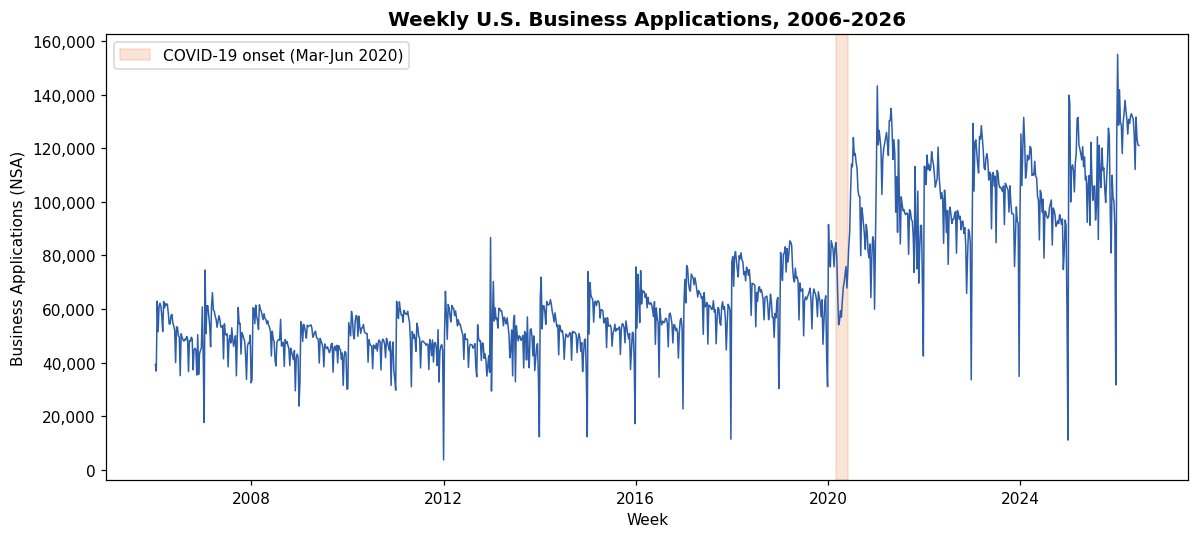

In [7]:
def plot_national_trend(data):
    '''Plot the weekly national total of business applications, highlighting COVID-19 onset.'''
    national = data.groupby('Start date', as_index=False)['BA_NSA'].sum()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(national['Start date'], national['BA_NSA'], color=COLOR, linewidth=1)
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'), color=ACCENT, alpha=0.2,
               label='COVID-19 onset (Mar-Jun 2020)')
    ax.set_title('Weekly U.S. Business Applications, 2006-2026', fontsize=13, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Business Applications (NSA)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()
    plt.tight_layout()
   


plot_national_trend(df)

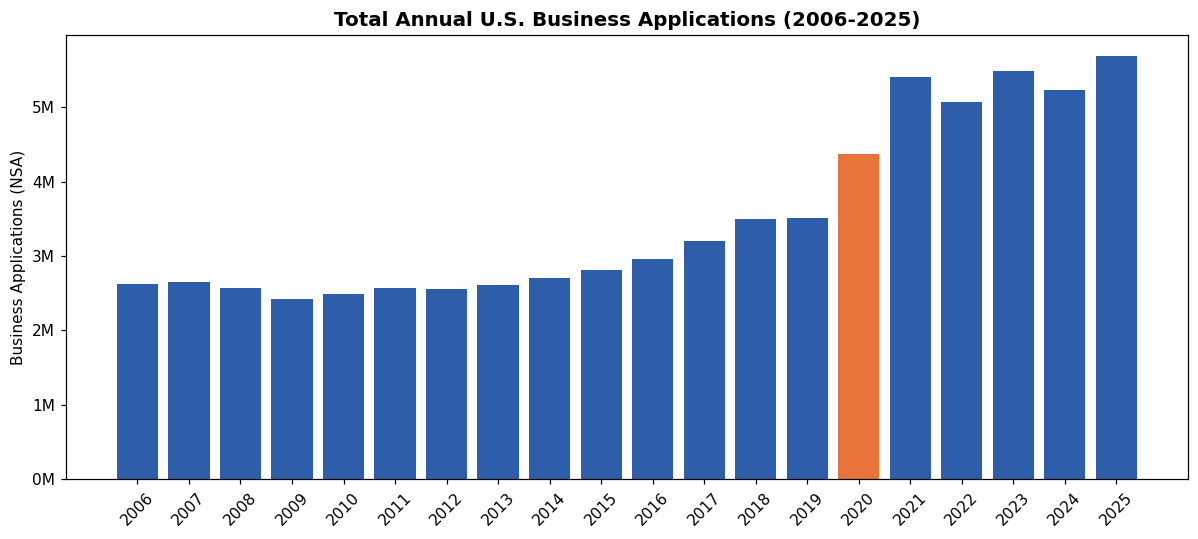

In [8]:
annual = full_years.groupby('Year', as_index=False)['BA_NSA'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
colors = [ACCENT if y == 2020 else COLOR for y in annual['Year']]
ax.bar(annual['Year'].astype(str), annual['BA_NSA'], color=colors)
ax.set_title('Total Annual U.S. Business Applications (2006-2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Business Applications (NSA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
plt.xticks(rotation=45)
plt.tight_layout()


In [9]:
pre_covid = annual.loc[annual['Year'] == 2019, 'BA_NSA'].values[0]
covid_year = annual.loc[annual['Year'] == 2020, 'BA_NSA'].values[0]
post_covid = annual.loc[annual['Year'] == 2021, 'BA_NSA'].values[0]
latest = annual.loc[annual['Year'] == annual['Year'].max(), 'BA_NSA'].values[0]

print(f"2019 -> 2020 change: {(covid_year - pre_covid) / pre_covid:+.1%}")
print(f"2020 -> 2021 change: {(post_covid - covid_year) / covid_year:+.1%}")
print(f"2019 -> 2021 change: {(post_covid - pre_covid) / pre_covid:+.1%}")
print(f"2019 -> {annual['Year'].max()} change: {(latest - pre_covid) / pre_covid:+.1%}")

2019 -> 2020 change: +24.4%
2020 -> 2021 change: +23.7%
2019 -> 2021 change: +53.9%
2019 -> 2025 change: +61.9%


**Answer:** National business applications grew steadily but modestly from 2006-2019 (from about 2.6M to 3.5M a
year), dipped through the 2008-2011 financial crisis, and then jumped dramatically at the onset of COVID-19: applications rose
about 24% from 2019 to 2020 and a further 24% from 2020 to 2021 — a combined **~54% increase in just two years**. Rather than
reverting after the pandemic, the higher rate of business formation has persisted: by 2025, applications remained roughly
double their pre-pandemic 2019 level. This is consistent with the well-documented "entrepreneurship boom" that followed the
pandemic, driven by remote work, e-commerce growth, and shifts in the labor market.

### Question 2 — Which U.S. states lead in business formation, in volume and in growth?

,State,BA_NSA
9,FL,7940740
4,CA,7210810
43,TX,6060860
34,NY,4494860
10,GA,3378750
14,IL,2502090
31,NJ,2241290
27,NC,2095720
38,PA,2019920
22,MI,1964530


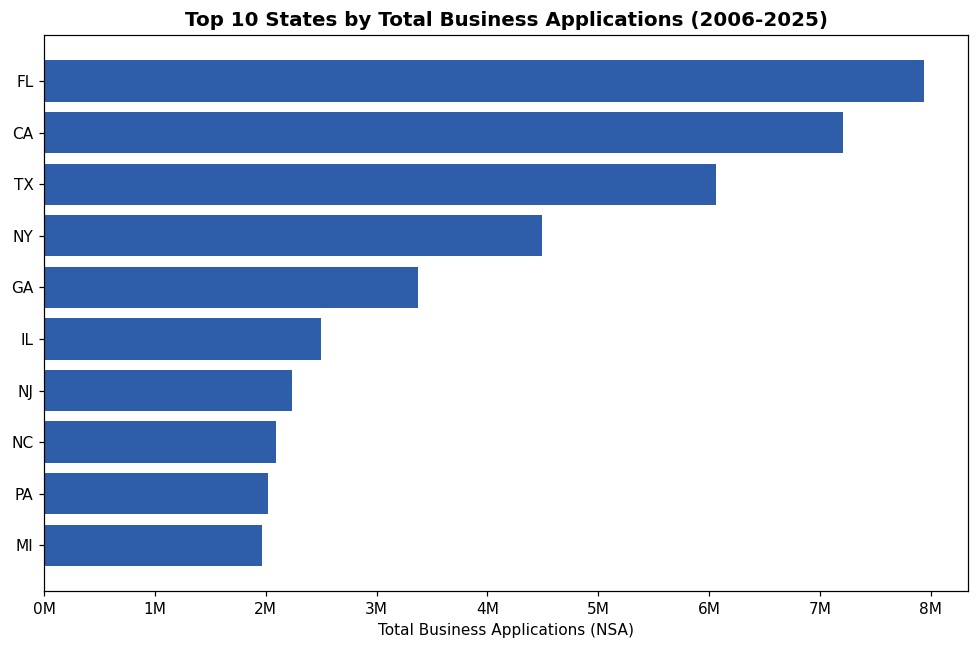

In [10]:
state_totals = (full_years.groupby('State', as_index=False)['BA_NSA']
                 .sum()
                 .sort_values('BA_NSA', ascending=False))
top10 = state_totals.head(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10['State'][::-1], top10['BA_NSA'][::-1], color=COLOR)
ax.set_title('Top 10 States by Total Business Applications (2006-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Business Applications (NSA)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
plt.tight_layout()


top10

Year,2015,2025,pct_growth
State,,,
WY,9930,79260,698.187311
DE,17190,60360,251.134380
NM,12980,40980,215.716487
MT,10830,30090,177.839335
WA,53730,142450,165.121906
KY,25300,64300,154.150198
SC,37660,94330,150.477961
AZ,57450,135890,136.536118
TN,44510,103460,132.442148


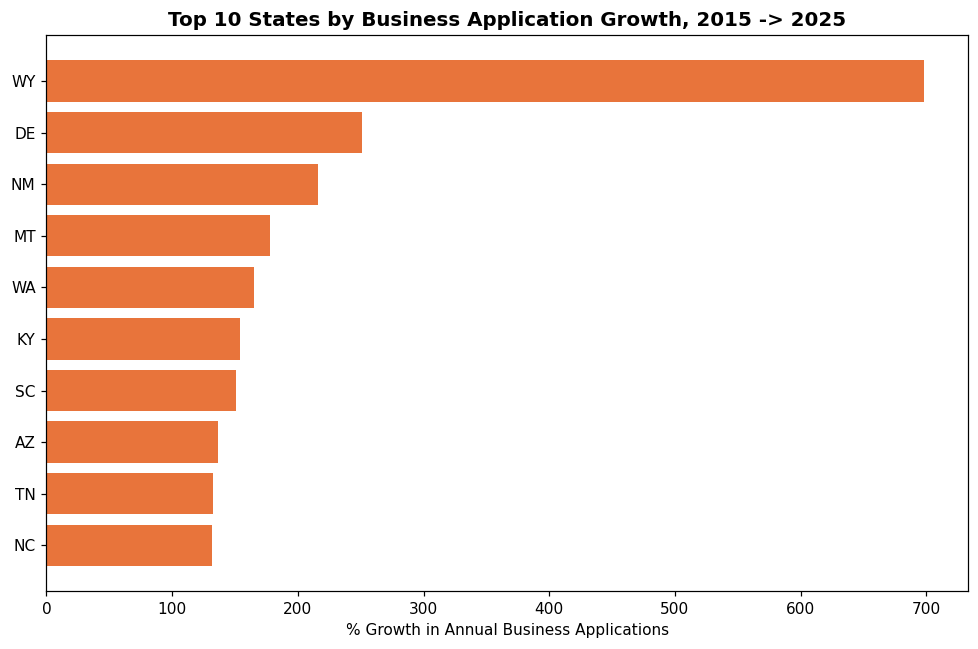

In [11]:
def state_growth(data, start_year, end_year):
    '''Compute each state's % growth in total annual business applications between two years.'''
    pivot = (data[data['Year'].isin([start_year, end_year])]
             .groupby(['State', 'Year'])['BA_NSA'].sum()
             .unstack())
    pivot['pct_growth'] = (pivot[end_year] - pivot[start_year]) / pivot[start_year] * 100
    return pivot.sort_values('pct_growth', ascending=False)


growth = state_growth(full_years, 2015, 2025)

fig, ax = plt.subplots(figsize=(9, 6))
top_growth = growth.head(10).sort_values('pct_growth')
ax.barh(top_growth.index, top_growth['pct_growth'], color=ACCENT)
ax.set_title('Top 10 States by Business Application Growth, 2015 -> 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('% Growth in Annual Business Applications')
plt.tight_layout()


growth.head(10)

**Answer:** In raw volume, **Florida, California, and Texas** are by far the largest generators of new business
applications (each has accumulated multiple millions of applications since 2006) — unsurprising, given they are three of the
four most populous U.S. states. But volume leadership and growth leadership are different stories: over the last decade
(2015-2025), the fastest-*growing* states for business formation were smaller, lower-cost states such as **Wyoming, Delaware,
New Mexico, and Montana**, some of which grew total applications several-fold. This pattern is consistent with entrepreneurs
increasingly forming businesses (particularly LLCs, which Wyoming and Delaware are well known for favorable treatment of) in
states other than where the largest, most established business hubs are.

### Question 3 — Is there a seasonal pattern to business applications?

Peak month: Mar
Lowest month: Dec


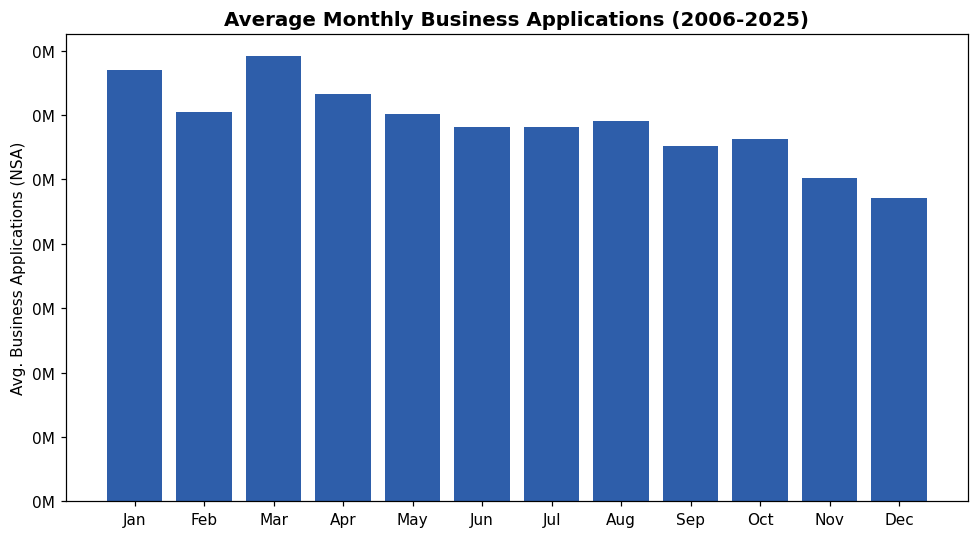

In [12]:
month_year = full_years.groupby(['Year', 'Month'], as_index=False)['BA_NSA'].sum()
month_avg = month_year.groupby('Month', as_index=False)['BA_NSA'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(month_names, month_avg['BA_NSA'], color=COLOR)
ax.set_title('Average Monthly Business Applications (2006-2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg. Business Applications (NSA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
plt.tight_layout()


peak_month = month_names[int(month_avg.loc[month_avg['BA_NSA'].idxmax(), 'Month']) - 1]
low_month = month_names[int(month_avg.loc[month_avg['BA_NSA'].idxmin(), 'Month']) - 1]
print(f'Peak month: {peak_month}')
print(f'Lowest month: {low_month}')

**Answer:** Yes — there is a clear seasonal pattern. Business applications peak in **Q1, especially January and
March** (the classic "New Year, new business" effect, and the start of many states' fiscal/tax years), and are consistently at
their **lowest in November and December**, likely because fewer people choose to start a new business during the
year-end holiday season. This is a useful, actionable finding for anyone timing a launch, a marketing campaign aimed at new
business owners, or seasonal staffing for agencies (e.g., registered-agent or accounting services) that support new filers.

### Question 4 — What share of applications are 'high-propensity,' and how has that changed?

High-propensity share in 2006: 59.1%
High-propensity share in 2025: 30.3%


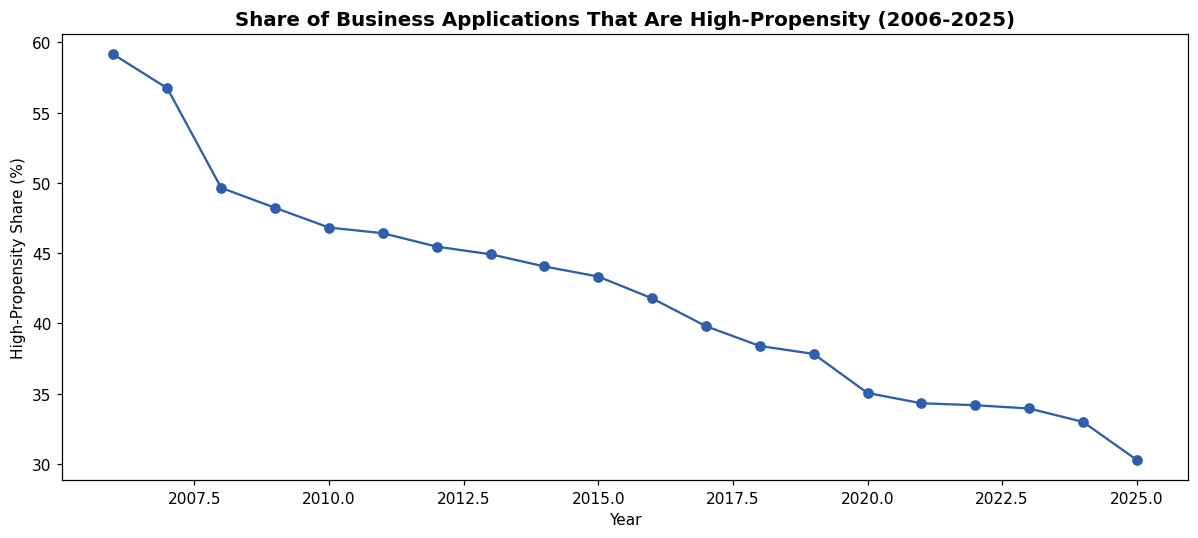

In [13]:
share = full_years.groupby('Year', as_index=False)[['BA_NSA', 'HBA_NSA']].sum()
share['hp_share'] = share['HBA_NSA'] / share['BA_NSA'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(share['Year'], share['hp_share'], marker='o', color=COLOR)
ax.set_title('Share of Business Applications That Are High-Propensity (2006-2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('High-Propensity Share (%)')
ax.set_xlabel('Year')
plt.tight_layout()


print(f"High-propensity share in 2006: {share.loc[share['Year']==2006, 'hp_share'].values[0]:.1f}%")
print(f"High-propensity share in 2025: {share.loc[share['Year']==2025, 'hp_share'].values[0]:.1f}%")

In [14]:
state_hp = full_years.groupby('State', as_index=False)[['BA_NSA', 'HBA_NSA']].sum()
state_hp['hp_share'] = state_hp['HBA_NSA'] / state_hp['BA_NSA'] * 100
state_hp.sort_values('hp_share', ascending=False).head(10)

,State,BA_NSA,HBA_NSA,hp_share
34,NY,4494860,2181860,48.541223
4,CA,7210810,3446360,47.794353
14,IL,2502090,1174570,46.943555
21,ME,199190,88530,44.445002
9,FL,7940740,3525960,44.403418
19,MA,1134860,492110,43.363058
46,VT,110900,46510,41.938683
39,RI,169700,70640,41.626400
28,ND,136950,56690,41.394670
42,TN,1172470,476700,40.657757


**Answer:** The share of applications classified as "high-propensity" (i.e., likely to become a real,
wage-paying employer business) has **fallen steadily**, from about 59% of all applications in 2006 to about 30% in 2025 — even
though the *raw number* of high-propensity applications has actually grown. In other words, the recent boom in business
applications (Question 1) is driven disproportionately by lower-propensity filings — likely a mix of side businesses, sole
proprietorships, and speculative filings that are less likely to ever hire an employee — rather than a proportional boom in
new, established-style employer businesses. New York, California, and Illinois have the highest high-propensity shares among
large states, suggesting more of their new filings reflect substantial, employer-track businesses.

### Question 5 — Can we predict weekly, state-level business applications, and which factors matter most?

To answer this we build a **Random Forest regression model** that predicts a state's weekly `BA_NSA` count from `Year`
(captures the long-run growth trend), `Week`/`Month` (captures seasonality), and `State` (captures each state's baseline
size/economic activity). `State` is a **categorical** variable with 51 levels and no natural ordering, so it is **one-hot
encoded** before being passed to the model — this preserves all the information in the category without imposing a false
numeric ordering on the states, and it is the standard approach for tree-based and linear models alike. A Random Forest was
chosen over a plain linear model because the relationship between these features (especially state-level scale) and the
target is highly non-linear.

In [15]:
def build_and_evaluate_model(data, random_state=42):
    '''Train a Random Forest to predict weekly BA_NSA from Year, Week, Month, and State.

    Parameters
    ----------
    data : pd.DataFrame
        Prepared data containing Year, Week, Month, State, and BA_NSA columns.
    random_state : int
        Seed for reproducibility of the train/test split and the model.

    Returns
    -------
    pipe : sklearn.pipeline.Pipeline
        The fitted preprocessing + model pipeline.
    metrics : dict
        R^2, MAE, and RMSE on the held-out test set.
    importances : pd.DataFrame
        Feature importances grouped by original feature (State's 51 dummies summed together).
    (X_test, y_test, preds) : tuple
        Held-out data and predictions, for further inspection/plotting.
    '''
    features = ['Year', 'Week', 'Month', 'State']
    X = data[features]
    y = data['BA_NSA']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    preprocessor = ColumnTransformer(
        transformers=[('state_ohe', OneHotEncoder(handle_unknown='ignore'), ['State'])],
        remainder='passthrough'
    )
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=random_state, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    metrics = {
        'R2': r2_score(y_test, preds),
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': mean_squared_error(y_test, preds) ** 0.5
    }

    ohe = pipe.named_steps['preprocess'].named_transformers_['state_ohe']
    state_names = list(ohe.get_feature_names_out(['State']))
    all_names = state_names + ['Year', 'Week', 'Month']
    raw_importances = pipe.named_steps['model'].feature_importances_
    imp = pd.DataFrame({'feature': all_names, 'importance': raw_importances})

    grouped = pd.DataFrame({
        'feature_group': ['State (51 dummies)', 'Year', 'Week', 'Month'],
        'importance': [
            imp[imp['feature'].str.startswith('State_')]['importance'].sum(),
            imp.loc[imp['feature'] == 'Year', 'importance'].values[0],
            imp.loc[imp['feature'] == 'Week', 'importance'].values[0],
            imp.loc[imp['feature'] == 'Month', 'importance'].values[0],
        ]
    }).sort_values('importance', ascending=False)

    return pipe, metrics, grouped, (X_test, y_test, preds)


pipe, metrics, importances, (X_test, y_test, preds) = build_and_evaluate_model(full_years)

print('Model performance on held-out test data:')
for k, v in metrics.items():
    print(f'  {k}: {v:,.3f}')

Model performance on held-out test data:
  R2: 0.906
  MAE: 396.083
  RMSE: 541.270


,feature_group,importance
0,State (51 dummies),0.801167
1,Year,0.162656
2,Week,0.022902
3,Month,0.013275


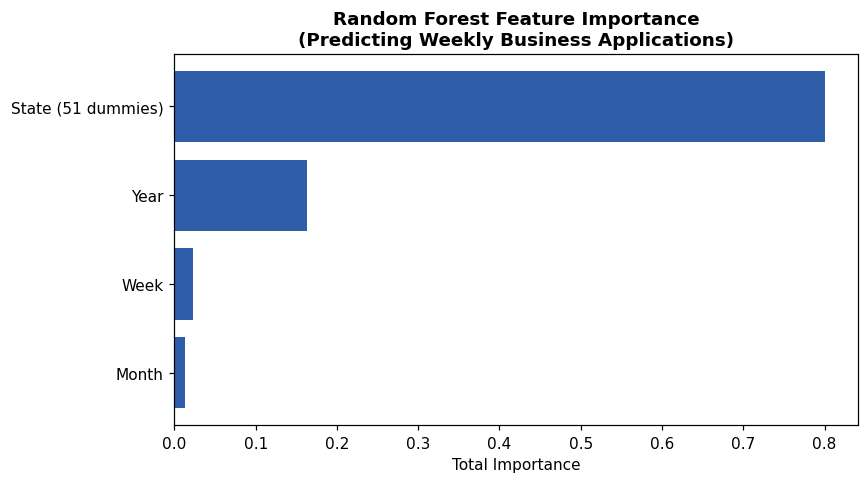

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importances['feature_group'][::-1], importances['importance'][::-1], color=COLOR)
ax.set_title('Random Forest Feature Importance\n(Predicting Weekly Business Applications)', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Importance')
plt.tight_layout()


importances

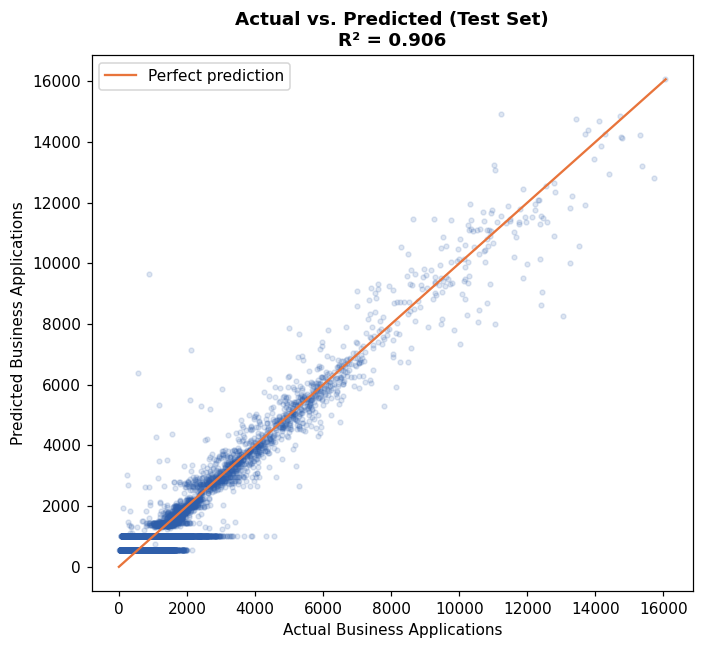

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, preds, alpha=0.15, s=10, color=COLOR)
lims = [0, max(y_test.max(), preds.max())]
ax.plot(lims, lims, color=ACCENT, linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Business Applications')
ax.set_ylabel('Predicted Business Applications')
ax.set_title(f"Actual vs. Predicted (Test Set)\nR\u00b2 = {metrics['R2']:.3f}", fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()


**Answer:** Yes — the model explains about **91% of the variance** (R² ≈ 0.91) in weekly, state-level business
applications, with a mean absolute error of roughly 400 applications per state-week. Looking at feature importance, **`State`
is by far the strongest predictor (~80% of total importance)** — which makes sense, since states differ enormously in
population and economic size, so "which state" tells you most of what you need to know about the expected scale of
applications. **`Year` is the second most important feature (~16%)**, reflecting the strong overall growth trend identified in
Question 1 (and especially the post-2020 step-up). **`Week` and `Month` contribute much less (under 4% combined)** — consistent
with Question 3's finding that seasonality exists but is a comparatively minor effect next to a state's baseline size and the
year-over-year growth trend.

## 5. Evaluation & Conclusion

Summarizing the findings across all five questions:

1. **National trend & COVID-19:** Business applications grew slowly from 2006-2019, then surged ~54% over 2019-2021 following
   the pandemic, and have stayed elevated (roughly double 2019 levels) ever since.
2. **State leadership:** Florida, California, and Texas dominate in raw application volume, but smaller states like Wyoming,
   Delaware, and New Mexico have grown the fastest over the last decade.
3. **Seasonality:** Applications peak in Q1 (especially January and March) and dip around November/December.
4. **High-propensity share:** The proportion of applications likely to become real employer businesses has fallen from ~59%
   (2006) to ~30% (2025), even as the raw count of high-propensity applications has grown — the recent boom is driven
   disproportionately by lower-propensity filings.
5. **Predictive modeling:** A Random Forest model predicts weekly, state-level applications with R² ≈ 0.91. `State` (baseline
   economic scale) and `Year` (growth trend) are by far the most important drivers; seasonality (`Week`/`Month`) plays a much
   smaller role.

**Limitations:** This analysis uses *not seasonally adjusted* (NSA) data by design (to study seasonality directly in Question
3), but that also means state-to-state and month-to-month comparisons partly reflect population differences rather than
underlying economic dynamism; a per-capita or seasonally adjusted view could sharpen the state comparisons in Question 2. The
Random Forest model in Question 5 is also a descriptive/interpretive tool rather than a causal one — it identifies which
factors are most *predictive*, not necessarily which factors *cause* changes in business formation.

**Acknowledgements:** Data provided by the U.S. Census Bureau's [Business Formation Statistics program](https://www.census.gov/econ/bfs/index.html).
